## 331 - Making an Emagram Plot

[Youtube](https://www.youtube.com/watch?v=ovyGAT5C3io)

In [1]:
import matplotlib.pyplot as plt
import metpy.calc as mpcalc
import numpy as np

from datetime import datetime
from metpy.plots import Emagram
from metpy.units import units, pandas_dataframe_to_unit_arrays
from siphon.simplewebservice.wyoming import WyomingUpperAir

In [2]:
date = datetime(2013, 5, 20, 18)
station = 'OUN'

In [3]:
df = WyomingUpperAir.request_data(date, station)

In [4]:
df.head()

,pressure,height,temperature,dewpoint,direction,speed,u_wind,v_wind,station,station_number,time,latitude,longitude,elevation,pw
0,966.0,345,27.4,22.4,185.0,10.0,0.871557,9.961947,OUN,72357,2013-05-20 18:00:00,35.18,-97.44,345.0,32.76
1,958.0,419,26.2,21.3,185.0,12.0,1.045869,11.954336,OUN,72357,2013-05-20 18:00:00,35.18,-97.44,345.0,32.76
2,937.6,610,24.1,19.6,185.0,16.0,1.394492,15.939115,OUN,72357,2013-05-20 18:00:00,35.18,-97.44,345.0,32.76
3,925.0,730,22.8,18.6,185.0,16.0,1.394492,15.939115,OUN,72357,2013-05-20 18:00:00,35.18,-97.44,345.0,32.76
4,914.0,834,21.6,17.9,193.0,18.0,4.049119,17.538661,OUN,72357,2013-05-20 18:00:00,35.18,-97.44,345.0,32.76


In [5]:
df = pandas_dataframe_to_unit_arrays(df)

In [6]:
type(df)

dict

In [7]:
df.keys()

dict_keys(['pressure', 'height', 'temperature', 'dewpoint', 'direction', 'speed', 'u_wind', 'v_wind', 'station', 'station_number', 'time', 'latitude', 'longitude', 'elevation', 'pw'])

In [8]:
type(df['pressure'])

pint.Quantity

In [9]:
df['pressure']

Magnitude,[966.0 958.0 937.6 925.0 914.0 905.6 876.0 874.3 850.0 844.0 835.0 825.0 820.0 814.0 813.0 794.0 789.0 785.4 781.0 757.6 730.6 700.0 653.5 606.0 586.0 561.1 539.6 524.0 503.0 500.0 492.0 479.0 400.0 390.6 343.8 342.0 326.0 315.0 302.0 300.0 278.0 250.0 238.0 224.0 219.0 218.2 211.0 202.0 200.0 199.0 191.0 187.0 173.0 159.0 152.0 150.0 149.3 137.0 134.0 129.1 129.0 122.8 121.0 119.0 118.0 116.9 107.0 100.0 88.4 84.6 81.2 79.8 74.5 70.0 67.4 63.6 61.0 59.2 58.0 56.4 55.3 52.6 50.1 50.0 49.7 48.2 45.5 43.9 43.3 39.5 39.3 37.5 32.5 31.0 30.9 30.0 29.5 29.4 28.1 25.6 24.4 22.5 22.2 21.1 20.2 20.0 19.2 18.6 17.5 16.7 14.0 13.0 11.9 11.1 10.9 10.6 10.2]
Units,hectopascal


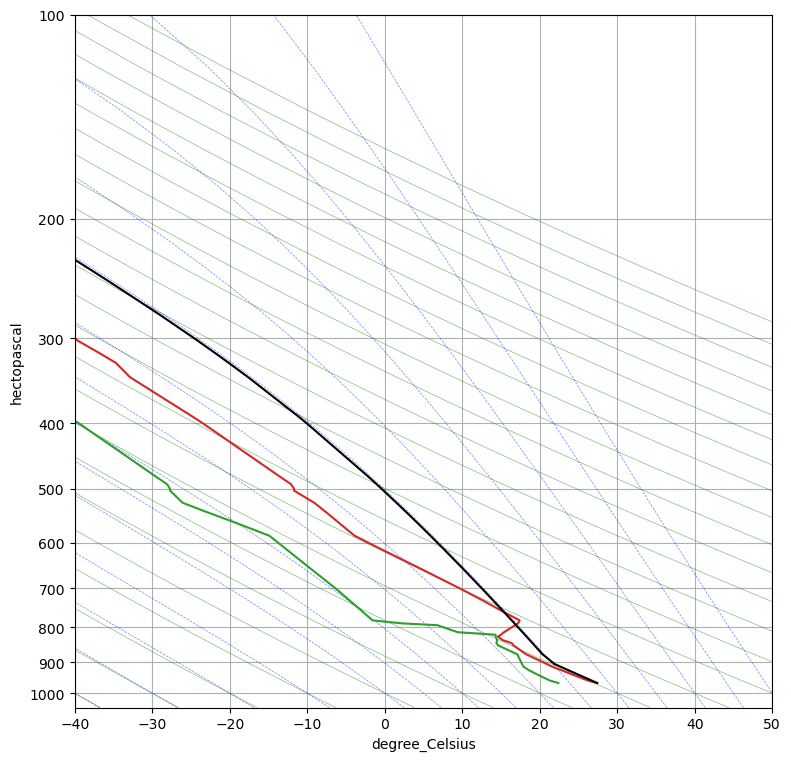

In [10]:
fig = plt.figure(figsize=(9,9))

emagram = Emagram(fig)

emagram.plot(df['pressure'], df['temperature'], 'tab:red')
emagram.plot(df['pressure'], df['dewpoint'], 'tab:green')

# Parcel profile
prof = mpcalc.parcel_profile(df['pressure'], df['temperature'][0], df['dewpoint'][0]).to('degC')
emagram.plot(df['pressure'], prof, 'k')

# Fiducial Lines
emagram.plot_dry_adiabats(colors='green', linestyle='-', linewidth=0.5, t0=np.arange(-40, 200, 10)*units.degC)
emagram.plot_moist_adiabats(linewidth=0.5)